# Objective

The exploratory analysis performed aims to understand the structure, distribution and relationships within SKU level data in order to uncover trends in demand, purchase, inventory levels and pricing that can guide further analysis including :

- Inventory Health Analysis
- Vendor Performance Analysis
- Product Performance Analysis
- Pricing Strategy Analysis

The goal is not to derive final business insights, but to:

- Identify key patterns and relations
- Detect data imbalances
- Understand metric behavior
- Decide what to analyze next

#### Importing libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sqlalchemy import create_engine,text
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

#### Connection setup and Reading required data

In [2]:
# load env file and import credentials
load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_HOST = os.getenv("DB_HOST")
DB_PASSWORD = os.getenv("DB_PASSWORD")

# establish connection to the 'inventory_db' database
conn_url = URL.create (
    drivername = "mysql+pymysql",
    host = DB_HOST,
    username = DB_USER,
    password = DB_PASSWORD,
    database = 'inventory_db'
)
conn_eng = create_engine(conn_url)
print("Connection Open to 'inventory_db' database")

Connection Open to 'inventory_db' database


In [4]:
# reading required datasets from the database
with conn_eng.connect() as conn:
    dataset = pd.read_sql(text("select * from product_summary;"), conn)
    begin_inv = pd.read_sql(text('''select ProductId,sum(onHand) as BeginInv
                                    from begin_inventory
                                    group by ProductId'''),conn)
print("(Rows, Columns) :",dataset.shape)
dataset.head(3)

(Rows, Columns) : (10485, 14)


,ProductId,Description,VendorNumber,VendorName,Volume_ml,ActualPrice,PurchasePrice,TotalQuantityPurchased,TotalPurchaseDollars,SalesPrice,TotalQuantitySold,TotalSalesDollars,GrossProfit,GrossProfitMargin
0,58,Gekkeikan Black & Gold Sake,8320,SHAW ROSS INT L IMP LTD,750,12.99,9.28,3550,32944.0,12.58,3446,43341.54,11362.66,26.22
1,62,Herradura Silver Tequila,1128,BROWN-FORMAN CORP,750,36.99,28.67,3200,91744.0,38.36,3125,119863.75,30270.00,25.25
2,63,Herradura Reposado Tequila,1128,BROWN-FORMAN CORP,750,38.99,30.46,2855,86963.3,40.41,2778,112249.22,27631.34,24.62


In [5]:
# calculating Sell Through Ratio (Quantity Sold / Available Inventory)
dataset = dataset.merge(begin_inv, on='ProductId', how='left')
dataset['SellThroughRatio'] = (dataset['TotalQuantitySold']/ 
                                     (dataset['TotalQuantityPurchased']+dataset['BeginInv'])).round(2)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10485 entries, 0 to 10484
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProductId               10485 non-null  int64  
 1   Description             10485 non-null  object 
 2   VendorNumber            10485 non-null  int64  
 3   VendorName              10485 non-null  object 
 4   Volume_ml               10485 non-null  int64  
 5   ActualPrice             10485 non-null  float64
 6   PurchasePrice           10485 non-null  float64
 7   TotalQuantityPurchased  10485 non-null  int64  
 8   TotalPurchaseDollars    10485 non-null  float64
 9   SalesPrice              10485 non-null  float64
 10  TotalQuantitySold       10485 non-null  int64  
 11  TotalSalesDollars       10485 non-null  float64
 12  GrossProfit             10485 non-null  float64
 13  GrossProfitMargin       10485 non-null  float64
 14  BeginInv                7272 non-null 

In [6]:
# check for duplicate rows
dataset.duplicated().sum()

np.int64(0)

In [7]:
# user defined functions to format values
def format_currency(value):
    if abs(value) >= 1000_000:
        return f"${round(value/1000_000,2)}M"
    elif abs(value) >= 1000:
        return f"${round(value/1000,2)}K"
    else:
        return f"${round(value,2)}"
    
def format_values(value):
    if abs(value) >= 1000_000:
        return f"{round(value/1000_000,2)}M"
    elif abs(value) >= 1000:
        return f"{round(value/1000,2)}K"
    else:
        return f"{round(value,2)}"

# KPI Overview

In [9]:
kpi_overview = pd.DataFrame(index= ['Total Vendors',
                            'Total Products',
                            'Total Revenue',
                            'Total Purchase Cost',
                            'Total Gross Profit',
                            'Average Profit Margin',
                            'Total Units Sold',
                            'Total Units Purchased',
                            'Sell Through Rate'],
                            data= [dataset['VendorNumber'].nunique(),
                                   dataset['Description'].nunique(),
                                   format_currency(dataset['TotalSalesDollars'].sum()),
                                   format_currency(dataset['TotalPurchaseDollars'].sum()),
                                   format_currency(dataset['GrossProfit'].sum()),
                                   f"{(dataset['GrossProfit'].sum()*100/
                                       dataset['TotalSalesDollars'].sum()) : .2f} %",
                                   format_values(dataset['TotalQuantitySold'].sum()),
                                   format_values(dataset['TotalQuantityPurchased'].sum()),
                                   f"{(dataset['TotalQuantitySold'].sum()*100/
                                    (dataset['TotalQuantityPurchased'].sum()+
                                     dataset['BeginInv'].sum())) : .1f} %"],
                            columns= ['Values'])
print("KPI Overview :")
display(kpi_overview)

KPI Overview :


,Values
Total Vendors,123
Total Products,9483
Total Revenue,$451.62M
Total Purchase Cost,$321.62M
Total Gross Profit,$138.47M
Average Profit Margin,30.66 %
Total Units Sold,32.9M
Total Units Purchased,33.57M
Sell Through Rate,87.1 %


> - The business operates at significant scale generating $451.62M in revenue with $138.5M in gross profit reflects strong commercial performance.
> - An average profit margin of 30.7% indicates stable and consistent margin realization across the portfolio.
> - Sales volume remains high with 32.9M units sold and closely aligned with 33.6M units purchased showing a balanced flow of goods.
> - A Sell Through Rate of 87.1% suggests most inventory is being converted into sales, though a portion remains unsold within the cycle.
> - With The presence of 123 vendors and around 9.5K products shows a wide portfolio contributing to scale but also adding operational complexity.

# Distribution Analysis

### Numerical Columns

In [10]:
# numerical columns
num_cols = dataset.select_dtypes(include='number').drop(labels=['VendorNumber','ProductId'], axis=1).columns
num_cols

Index(['Volume_ml', 'ActualPrice', 'PurchasePrice', 'TotalQuantityPurchased',
       'TotalPurchaseDollars', 'SalesPrice', 'TotalQuantitySold',
       'TotalSalesDollars', 'GrossProfit', 'GrossProfitMargin', 'BeginInv',
       'SellThroughRatio'],
      dtype='object')

In [11]:
dataset[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Volume_ml,10485.0,848.129995,668.563026,50.00,750.00,750.00,750.00,20000.00
ActualPrice,10485.0,34.380362,126.846106,0.49,10.99,15.99,28.99,5799.99
PurchasePrice,10485.0,23.436631,92.294757,0.36,6.84,10.44,19.40,4264.70
TotalQuantityPurchased,10485.0,3201.682976,11202.536508,1.00,36.00,280.00,2029.00,337660.00
TotalPurchaseDollars,10485.0,30674.161362,124284.696239,0.71,479.52,3831.00,21412.30,3811251.60
SalesPrice,10485.0,33.828752,126.413160,0.49,10.43,15.49,27.99,5799.99
TotalQuantitySold,10485.0,3138.238722,11058.549418,1.00,36.00,279.00,1990.00,334939.00
TotalSalesDollars,10485.0,43073.335453,169298.720265,1.98,809.82,5585.86,29613.06,5101919.51
GrossProfit,10485.0,13206.633665,48189.319326,-24762.39,246.81,1572.00,9131.98,1370292.28
GrossProfitMargin,10485.0,31.738581,9.312349,-174.58,28.25,32.89,35.46,83.40


#####  Product Volume Size(ml)

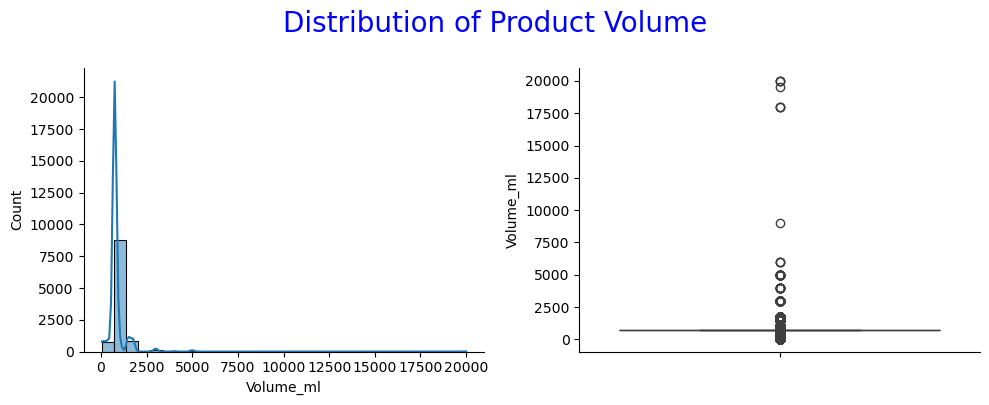

In [12]:
fig,ax=plt.subplots(1,2,figsize=(10,4))

sns.histplot(x=dataset['Volume_ml'],kde=True,bins=30, ax=ax[0])
sns.boxplot(y=dataset['Volume_ml'])

plt.suptitle('Distribution of Product Volume', fontsize=20, color='blue', y=1)
sns.despine()
plt.tight_layout()
plt.show()

> Product volume distribution is highly right-skewed, with a dominant peak at 750 ml, indicating the standard     bottle size in the dataset. A long tail extends up to 20,000 ml, representing bulk packaging formats.

In [13]:
bins = [0,5000,float('inf')]
labels = ['Regular (<5L)','Bulk (>5L)']
dataset['SizeSegment'] = pd.cut(dataset['Volume_ml'], bins= bins, labels= labels)
print("Average Pricing for different sized products :")
dataset.groupby('SizeSegment',observed=False)[['ActualPrice','PurchasePrice','SalesPrice']].mean().round(2)

Average Pricing for different sized products :


,ActualPrice,PurchasePrice,SalesPrice
SizeSegment,,,
Regular (<5L),34.18,23.31,33.63
Bulk (>5L),224.26,146.38,220.99


> The records with high product volumes were retained as valid observations since associated pricing scale proportionally, indicating legitimate bulk transactions rather than data errors.

##### Financial fields

In [14]:
fin_cols = ['TotalSalesDollars','TotalPurchaseDollars']
dataset[fin_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalSalesDollars,10485.0,43073.335453,169298.720265,1.98,809.82,5585.86,29613.06,5101919.51
TotalPurchaseDollars,10485.0,30674.161362,124284.696239,0.71,479.52,3831.00,21412.30,3811251.60


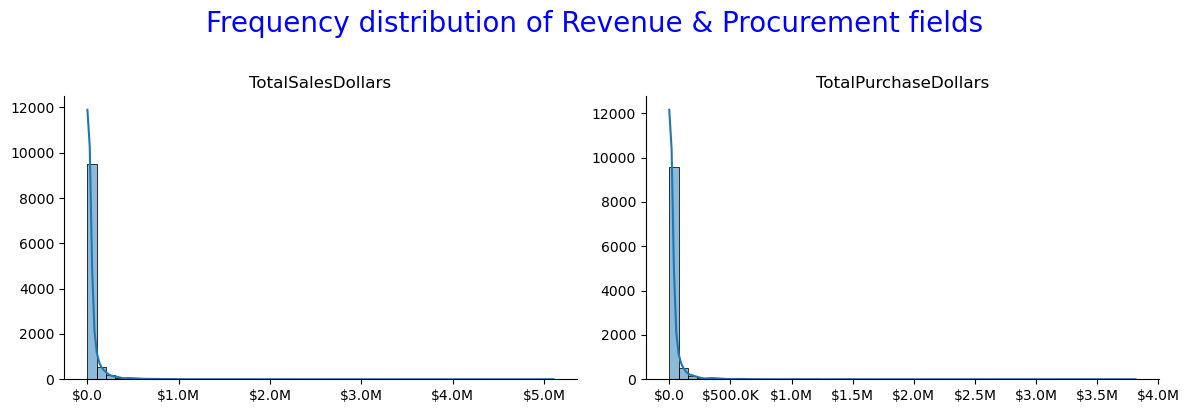

In [15]:
plt.figure(figsize=(12,4))
for i,col in enumerate(fin_cols):
    plt.subplot(1,2,i+1)
    sns.histplot(data=dataset[col], kde=True, bins=50)
    ax=plt.gca()
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : format_currency(x)))
plt.suptitle("Frequency distribution of Revenue & Procurement fields",color='blue',fontsize=20, y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

> Sales & Purchase distribution both are heavly rightly skewed, also indicated by mean and median values as       
> for Sales : Mean ~ $43K ,Median ~ $5.6K   ,for Purchase : Mean ~ $30K, Median ~ $3.9K.           
> This tells few vendors/products drive most revenue,therefore procurement is concentrated on same vendors/products.

In [16]:
profit_cols = ['GrossProfit', 'GrossProfitMargin']
dataset[profit_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
GrossProfit,10485.0,13206.633665,48189.319326,-24762.39,246.81,1572.00,9131.98,1370292.28
GrossProfitMargin,10485.0,31.738581,9.312349,-174.58,28.25,32.89,35.46,83.40


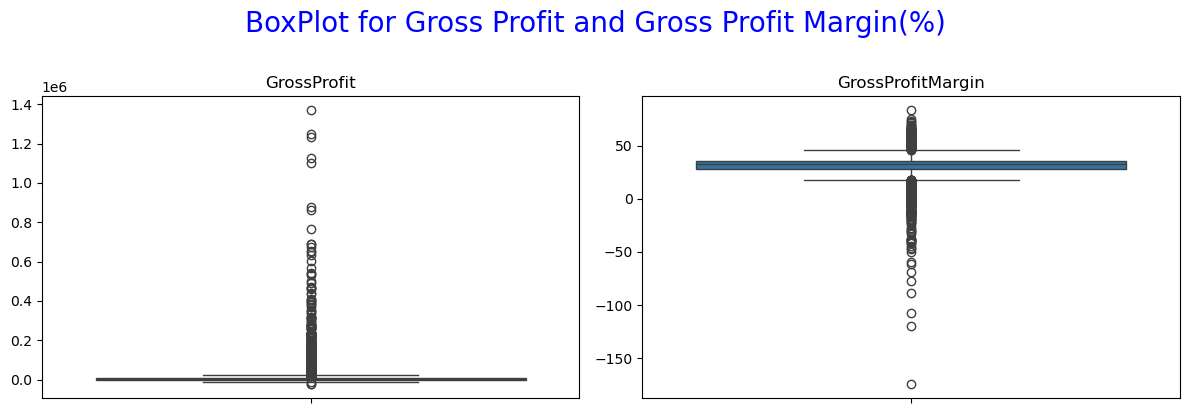

In [17]:
plt.figure(figsize=(12,4))
for i,col in enumerate(profit_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(y=dataset[col])
    ax=plt.gca()
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.suptitle("BoxPlot for Gross Profit and Gross Profit Margin(%)",color='blue',fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

> - Gross Profit: Minimum value is around -$25k, indicating losses. Some products may be selling at a loss due to higher cost or at discounted price lower than the purchase price.Margin is also negative for such transactions.  
> - Gross Profit Margin is as low as -150 % indicating some products may be distributed as sample at negligible price.

##### Pricing distribution

In [18]:
price_cols = ['ActualPrice', 'PurchasePrice', 'SalesPrice']
dataset[price_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ActualPrice,10485.0,34.380362,126.846106,0.49,10.99,15.99,28.99,5799.99
PurchasePrice,10485.0,23.436631,92.294757,0.36,6.84,10.44,19.40,4264.70
SalesPrice,10485.0,33.828752,126.413160,0.49,10.43,15.49,27.99,5799.99


> - The price range for each of the field is wide ,indicating a wide range of segments.  
> - The low price values indicate products purchased or sold in bulk quantity, or distributed or procured as samples.  
> - The high price values are significantly higher than the mean values, indicating potential premium products or products with large storage volume as found earlier.

In [19]:
# Premium Product
dataset.loc[dataset['PurchasePrice'].idxmax(),:]

ProductId                                  2367
Description                  Glenmorangie Pride
VendorNumber                               8112
VendorName                MOET HENNESSY USA INC
Volume_ml                                  1000
ActualPrice                             5799.99
PurchasePrice                            4264.7
TotalQuantityPurchased                        2
TotalPurchaseDollars                     8529.4
SalesPrice                              5799.99
TotalQuantitySold                             1
TotalSalesDollars                       5799.99
GrossProfit                             1535.29
GrossProfitMargin                         26.47
BeginInv                                    2.0
SellThroughRatio                           0.25
SizeSegment                       Regular (<5L)
Name: 6459, dtype: object

> The max value for each of Actual Price, Purchase Price and Sales Price is recorded for this single record.

##### Product movement fields

In [20]:
mov_cols = ['TotalQuantitySold', 'TotalQuantityPurchased','SellThroughRatio']
dataset[mov_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalQuantitySold,10485.0,3138.238722,11058.549418,1.00,36.00,279.00,1990.00,334939.0
TotalQuantityPurchased,10485.0,3201.682976,11202.536508,1.00,36.00,280.00,2029.00,337660.0
SellThroughRatio,7272.0,0.788502,0.177817,0.01,0.72,0.83,0.91,1.0


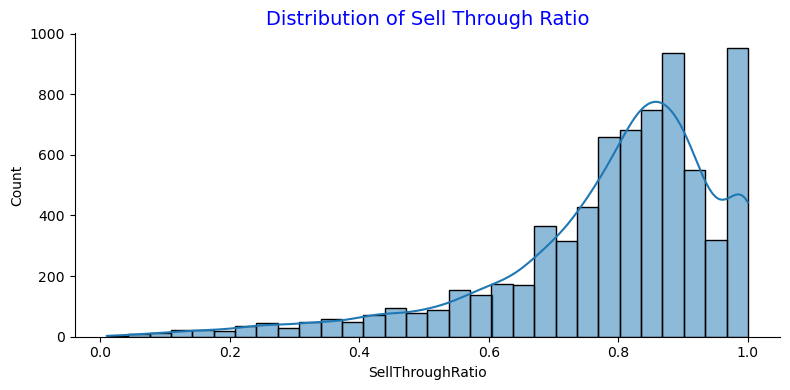

In [21]:
plt.figure(figsize=(8,4))

sns.histplot(x=dataset['SellThroughRatio'],kde=True,bins=30)

plt.title('Distribution of Sell Through Ratio', fontsize=14, color='blue', y=1)

sns.despine()
plt.tight_layout()
plt.show()

> - For quantity sold and purchased, large gap between mean and median (mean > median) suggest revenue and procurement concentration on few products as indicated earlier.  
> - Sell Through Ratio being left skewed ranges from 0 to 1, implying that while many products sell extremely fast some remain in stock indefinitely, suggesting potential overstock or weak demand.

### Categorical Columns

In [22]:
# categorical columns
cat_cols = dataset.select_dtypes(include = 'object').columns
cat_cols

Index(['Description', 'VendorName'], dtype='object')

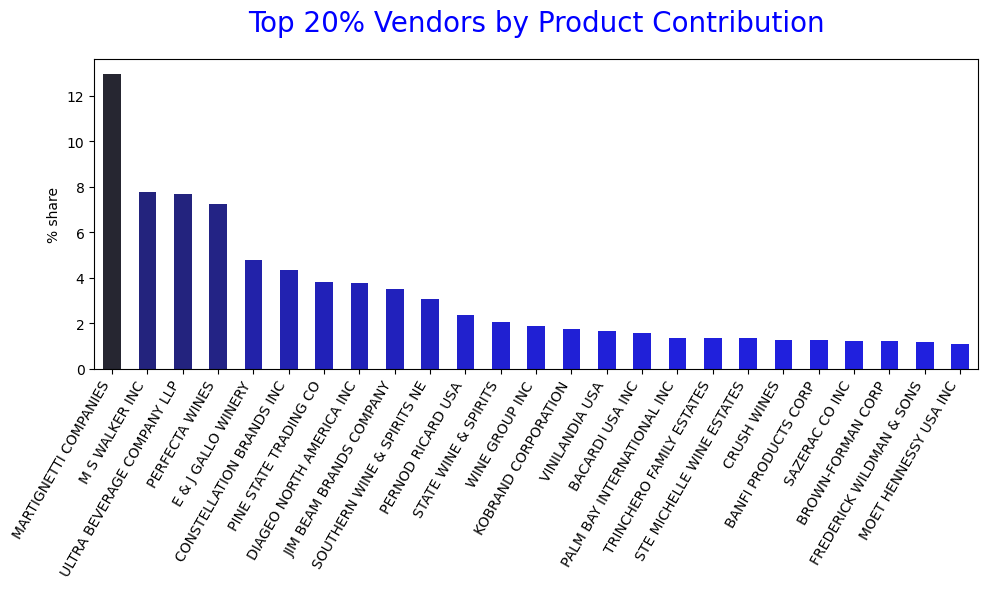

In [23]:
plt.figure(figsize=(10,6))

n= int(dataset['VendorName'].nunique()*0.2)
df_plot = (dataset['VendorName'].value_counts(normalize=True)*100).head(n).reset_index()
sns.barplot(data=df_plot,x='VendorName',y='proportion',hue='proportion',palette='dark:b_r',width=0.5,legend=False)

plt.title('Top 20% Vendors by Product Contribution', color='blue', fontsize=20, pad=20)
plt.xlabel('')
plt.ylabel('% share')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

> The vendor % share distribution shows that a few vendors contribute a large portion of products, while many vendors contribute less.

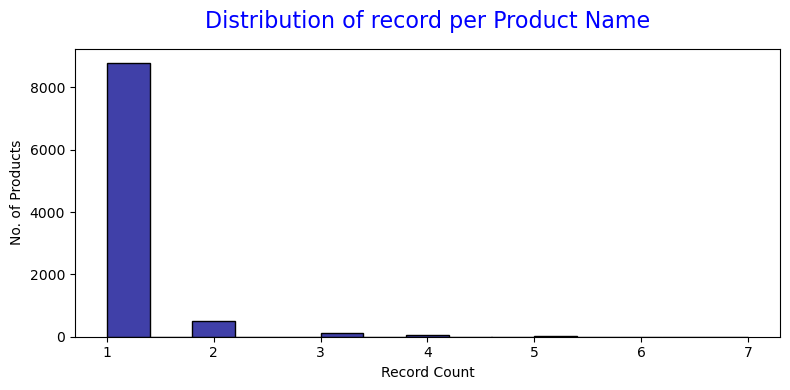

In [24]:
plt.figure(figsize=(8,4))

df_plot= dataset['Description'].value_counts().reset_index()
sns.histplot(data=df_plot['count'], color='darkblue')

plt.title('Distribution of record per Product Name', color='blue', fontsize=16, pad =15)
plt.xlabel('Record Count')
plt.ylabel('No. of Products')
plt.tight_layout()
plt.show()

> The distribution of product name record counts is heavily concentrated at a frequency of one, with over 8,000 products appearing only once in the dataset.  
The number of products declines sharply as frequency increases, suggesting the majority of products appear only once in the dataset with very few product names appear multiple times.

# Correlation Analysis

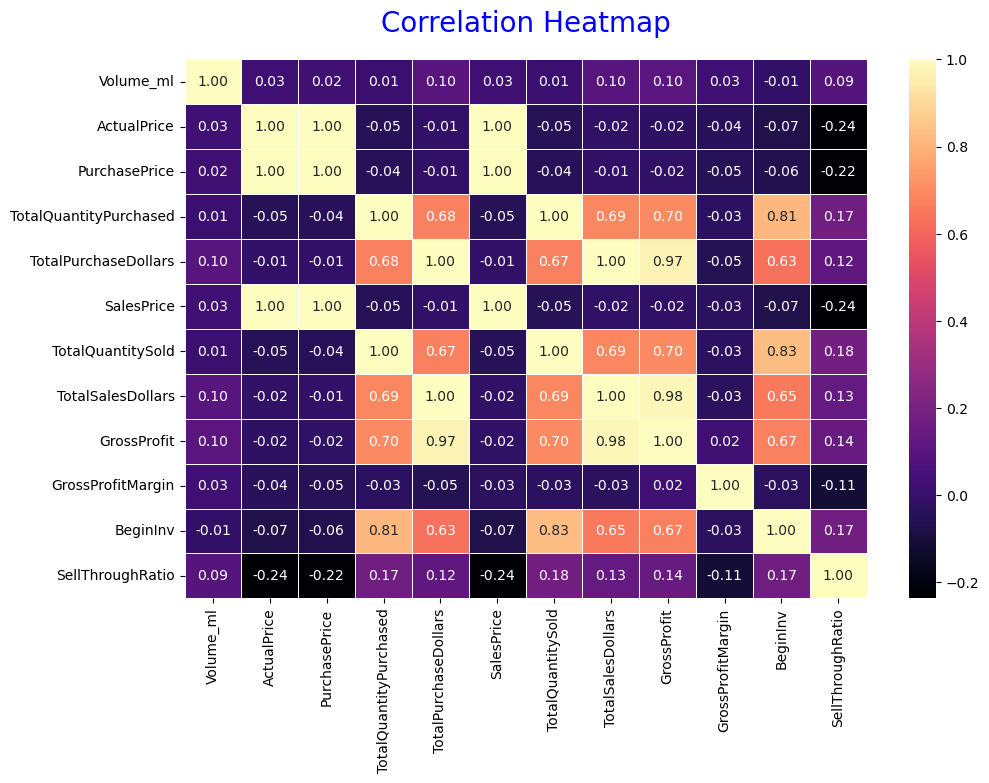

In [25]:
# Plotting Heat map to see correlation among different numerical variables
plt.figure(figsize=(11,7))
sns.heatmap(data=dataset[num_cols].corr(),annot=True,cmap='magma',fmt='.2f',linewidths=0.5)
plt.title('Correlation Heatmap', fontsize = 20, color='blue', pad=20)
plt.show()

> - Purchase Price and Sales Price are strongly correlated, indicating a consistent markup strategy where sales price is primarly determined by procurement cost.

> - Price variables exhibit weak correlations with quantities sold and purchased, suggesting that product demand is not very price-sensitive and mainly influenced more by product characteristics or market factors.

> - Purchased Quantity and Sold Quantity are strongly correlated.This indicates good stock efficiency i.e our purchase is well aligned with the demand.  

> - Total Sales Dollars and Total Purchase Dollars show strong positive correlations with Gross Profit, which is expected since profit is directly derived from these variables.

> - Total Sales Dollars and Total Purchase Dollars exhibit weak negative correlations with Gross Profit Margin, indicating that higher revenue products tend to operate at slightly lower percentage margins. This suggests a volume-driven sales strategy where larger transactions generate higher absolute profits despite tighter margins.

> - Gross Profit Margin exhibits weak correlations with most operational variables such as sales volume, purchase volume, and total revenue. This indicates that profitability percentage is primarily driven by pricing strategy rather than transaction scale.


> - Sell through ratio correlation with Gross Profit is weak but positive indicating some alignment between profitability and faster selling of products but profitability is not solely driven by sales velocity.


# Relationship Analysis

##### Sales Volume vs Gross Profit

In [26]:
dataset[['TotalQuantitySold', 'GrossProfit']].corr().round(2)

,TotalQuantitySold,GrossProfit
TotalQuantitySold,1.0,0.7
GrossProfit,0.7,1.0


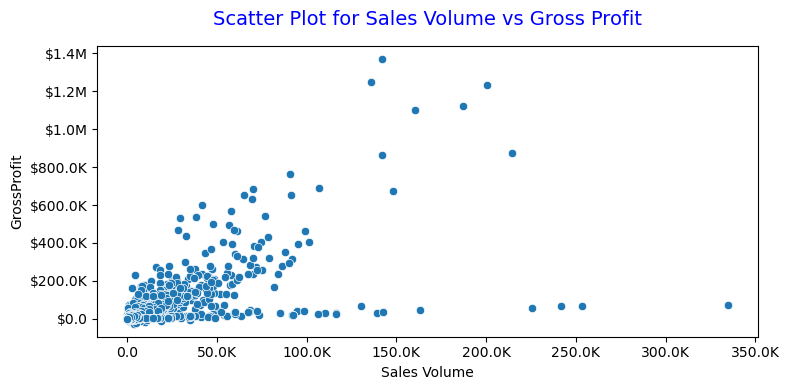

In [27]:
plt.figure(figsize=(8,4))

sns.scatterplot(data=dataset, x='TotalQuantitySold', y='GrossProfit')
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : format_currency(x)))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: format_values(x)))

plt.xlabel('Sales Volume')
plt.title('Scatter Plot for Sales Volume vs Gross Profit', color='blue',fontsize=14, pad=15)

plt.tight_layout()
plt.show()

> - The scatter plot shows a strong positive relationship between sales volume and gross profit (correlation = 0.7), indicating that higher sales volumes generally lead to higher profitability.  
> However, the distribution reveals a long-tail structure where most products contribute minimal profit, while a small group of products drives significant profit.  
> - Additionally, some high sales volume products operate at relatively low profit levels, suggesting a volume-driven sales strategy with thin margins for certain items.

##### Sales Volume vs Sales Price

In [28]:
dataset[['TotalQuantitySold','SalesPrice']].corr().round(2)

,TotalQuantitySold,SalesPrice
TotalQuantitySold,1.00,-0.05
SalesPrice,-0.05,1.00


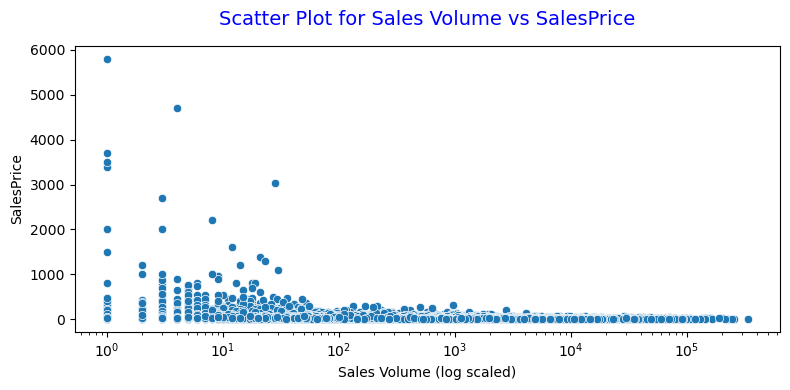

In [29]:
plt.figure(figsize=(8,4))

sns.scatterplot(data=dataset, x='TotalQuantitySold', y='SalesPrice')

plt.xlabel('Sales Volume (log scaled)')
plt.title('Scatter Plot for Sales Volume vs SalesPrice', color='blue',fontsize=14, pad=15)

plt.xscale('log')
plt.tight_layout()
plt.show()

> - The correlation between Sales Price and Sales Volume is -0.05, indicating no significant relationship between pricing and demand.  
> - After log-scaling sales volume, the scatter plot suggests two product segments: low price high volume mass products and high price low volume premium or bulk storage volume(ml) products.  
> - Overall Pricing alone does not appear to be a key driver of Sales Volume implying that demand is more likely influenced by product characteristics or other market factors.

##### Purchase Price vs Gross Profit Margin

In [30]:
dataset[['PurchasePrice', 'GrossProfitMargin']].corr().round(2)

,PurchasePrice,GrossProfitMargin
PurchasePrice,1.00,-0.05
GrossProfitMargin,-0.05,1.00


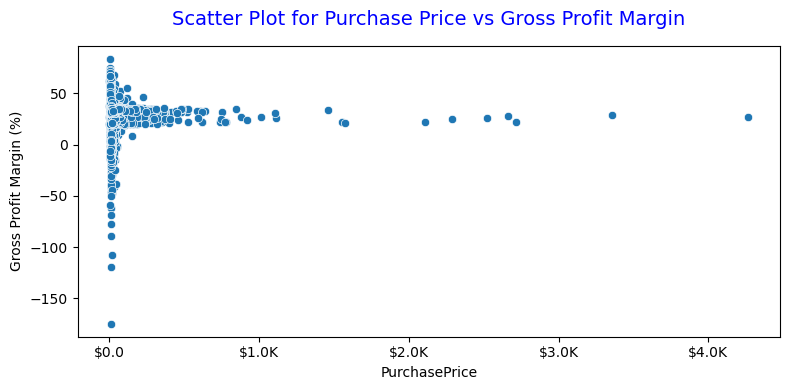

In [31]:
plt.figure(figsize=(8,4))

sns.scatterplot(data=dataset, x='PurchasePrice', y='GrossProfitMargin')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : format_currency(x)))

plt.ylabel('Gross Profit Margin (%)')
plt.title('Scatter Plot for Purchase Price vs Gross Profit Margin', color='blue',fontsize=14, pad=15)

plt.tight_layout()
plt.show()

> - The correlation between purchase price and gross profit margin is -0.05, indicating no significant effect of procurement cost on profit margin.  
> - Most products maintain consistent margin around 30-40%, suggesting a relatively consistent markup strategy across the inventory.  
> However, low-cost products exhibit high margin variability, including several negative-margin outliers, which may indicate discounting or clearance sales.

##### Sales Volume vs Purchase Volume

In [32]:
dataset[['TotalQuantitySold','TotalQuantityPurchased']].corr().round(3)

,TotalQuantitySold,TotalQuantityPurchased
TotalQuantitySold,1.000,0.999
TotalQuantityPurchased,0.999,1.000


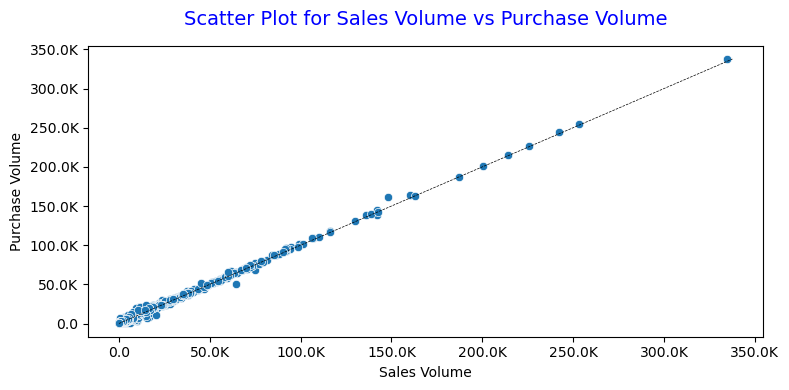

In [33]:
fig = plt.figure(figsize=(8,4))

sns.scatterplot(data=dataset, x='TotalQuantitySold', y='TotalQuantityPurchased')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : format_values(x)))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : format_values(x)))

ax.plot([0, dataset['TotalQuantityPurchased'].max()],
        [0, dataset['TotalQuantityPurchased'].max()], linestyle='--', color='black', linewidth = 0.5)

plt.xlabel('Sales Volume')
plt.ylabel('Purchase Volume')
plt.title('Scatter Plot for Sales Volume vs Purchase Volume', color='blue',fontsize=14, pad=15)

plt.tight_layout()
plt.show()

> - The correlation between purchase volume and sales volume is 0.999, indicating an almost perfect positive relationship.  
> - The scatter plot shows that procurement closely tracks sales demand, suggesting an efficient inventory management strategy with minimal overstocking.  
> However, as observed earlier revenue and procurement are both concentrated on few vendors/products, therefore this strong correlation may be driven by few products rather than entire product range.

---
# Key Insights
#### 1. Revenue & Procurement Concentration
Revenue and procurement are concentrated in a small subset of products and vendors, showing strong dependence on a limited core portfolio.

#### 2. Weak Price –Demand Relationship
Pricing does not show a strong influence on demand, indicating that sales are likely driven more by product characteristics or vendor factors than price changes.

#### 3. Sales Volume vs Margin Imbalance
Some high selling products generate relatively low profits, indicating a mix of volume-driven and margin driven products within the portfolio.

#### 4. Profitability Driven by Pricing
Profitability varies more with pricing and cost structure than with sales volume, making pricing a key factor in profit generation.

#### 5. High Sell-Through with Skewed Distribution
Sell through is generally high across products, with most products performing well and a smaller group showing lower movement.

---

---